# Sífilis em Ilhéus e Itabuna - consolidação e limpeza

Este notebook consolida os arquivos de sífilis adquirida, sífilis em gestante e sífilis congênita. O recorte principal é o município de residência em Ilhéus e Itabuna. A Bahia é mantida como base de comparação.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def encontrar_projeto():
    for candidato in [Path.cwd(), *Path.cwd().parents]:
        if (candidato / "Dados").exists() and (candidato / "Sifilis").exists():
            return candidato
        if (candidato / "DataSUS" / "Dados").exists():
            return candidato / "DataSUS"
    raise FileNotFoundError("Não foi possível localizar a pasta DataSUS.")

PROJECT_DIR = encontrar_projeto()
SIFILIS_DIR = PROJECT_DIR / "Sifilis"
DATA_DIR = PROJECT_DIR / "Dados"
OUTPUT_DIR = SIFILIS_DIR / "dados_processados"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(SIFILIS_DIR) not in sys.path:
    sys.path.insert(0, str(SIFILIS_DIR))

from sifilis_utils import (
    ANOS_ESPERADOS,
    CODIGOS_CIDADES,
    TIPOS_SIFILIS,
    carregar_agregados_demograficos,
    carregar_agregados_especificos,
    carregar_agregados_qualidade,
    carregar_agregados_temporais,
    carregar_base_cidades,
    caminho_artefato,
    exigir_cache_processado,
    exibir_markdown,
    formatar_inteiro,
    formatar_percentual,
    ler_tabela,
    processar_sifilis,
    salvar_figura,
    verificar_cache_processado,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 10

In [3]:
REPROCESSAR = False
processar_sifilis(force=REPROCESSAR, pasta_dados=DATA_DIR, pasta_saida=OUTPUT_DIR)
status_cache = verificar_cache_processado(OUTPUT_DIR)
assert status_cache["ok"], f"Cache incompleto: {status_cache['faltantes']}"

resumo_arquivos = ler_tabela("sifilis_resumo_arquivos", pasta_saida=OUTPUT_DIR)
df_cidades = carregar_base_cidades(OUTPUT_DIR)
temporais = carregar_agregados_temporais(OUTPUT_DIR)
cidades_ano = temporais["sifilis_cidades_ano"]
cidades_ano_completo = temporais["sifilis_cidades_ano_completo"]
cidades_mes = temporais["sifilis_cidades_mes"]
bahia_ano = temporais["sifilis_bahia_ano"]
bahia_mes = temporais["sifilis_bahia_mes"]
participacao_ano = temporais["sifilis_representatividade_bahia_tipo"]

assert len(resumo_arquivos) == 33, "A quantidade de arquivos lidos não corresponde aos 33 arquivos esperados."
assert set(resumo_arquivos["agravo_codigo"]) == {"SIFA", "SIFG", "SIFC"}
assert set(df_cidades["cidade"].dropna()) == {"Ilhéus", "Itabuna"}
resumo_arquivos.head()

,arquivo,agravo_codigo,tipo_sifilis,ano_arquivo,linhas_nacionais,linhas_bahia_residencia,linhas_ilheus_itabuna
0,SIFABR14.csv,SIFA,Sífilis adquirida,2014,49265,1464,112
1,SIFABR15.csv,SIFA,Sífilis adquirida,2015,68578,2206,122
2,SIFABR16.csv,SIFA,Sífilis adquirida,2016,90651,3551,152
3,SIFABR17.csv,SIFA,Sífilis adquirida,2017,121637,4783,151
4,SIFABR18.csv,SIFA,Sífilis adquirida,2018,160489,9464,229


In [ ]:
total_bahia = int(resumo_arquivos["linhas_bahia_residencia"].sum())
total_cidades = len(df_cidades)
participacao = total_cidades / total_bahia * 100 if total_bahia else 0
por_tipo = df_cidades.groupby("tipo_sifilis").size().sort_values(ascending=False)
principal_tipo = por_tipo.index[0]
principal_total = por_tipo.iloc[0]


### Observações da consolidação

Foram lidos 33 arquivos. A base com residência na Bahia soma 114.346 registros. O recorte de Ilhéus e Itabuna soma 3.810 registros, o que corresponde a 3,3% dos registros da Bahia nos três tipos de sífilis. No recorte das duas cidades, Sífilis adquirida concentra 2.209 registros.


A base com residência na Bahia soma 114.346 registros. O recorte de Ilhéus e Itabuna soma 3.810 registros, o que corresponde a 3,3% dos registros da Bahia nos três tipos de sífilis. No recorte das duas cidades, Sífilis adquirida concentra 2.209 registros.

## Volume por tipo e ano do arquivo

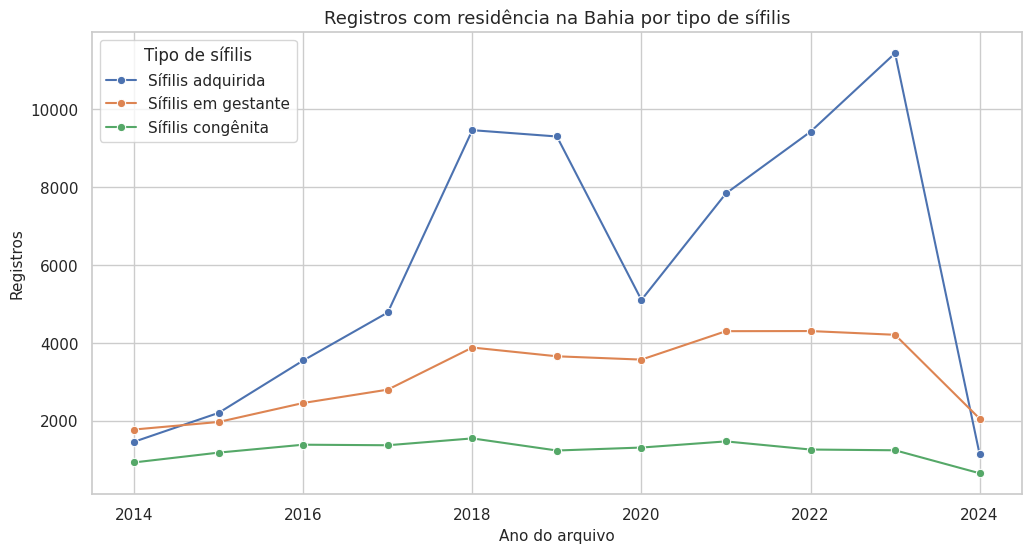

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=resumo_arquivos,
    x="ano_arquivo",
    y="linhas_bahia_residencia",
    hue="tipo_sifilis",
    marker="o",
    ax=ax,
)
ax.set_title("Registros com residência na Bahia por tipo de sífilis")
ax.set_xlabel("Ano do arquivo")
ax.set_ylabel("Registros")
ax.legend(title="Tipo de sífilis")
salvar_figura(fig, OUTPUT_DIR, "01_bahia_por_tipo_ano.png")
plt.show()

## Recorte de Ilhéus e Itabuna

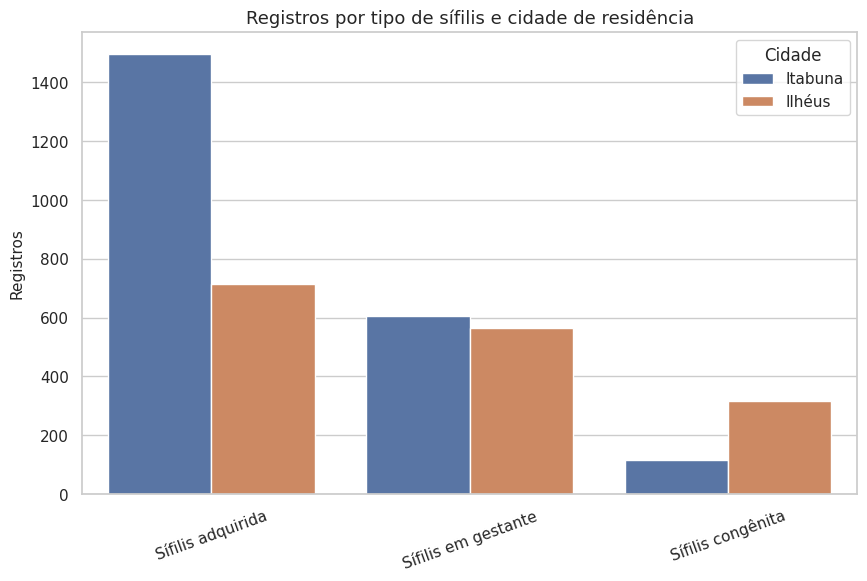

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ordem = df_cidades.groupby("tipo_sifilis").size().sort_values(ascending=False).index
sns.countplot(data=df_cidades, x="tipo_sifilis", hue="cidade", order=ordem, ax=ax)
ax.set_title("Registros por tipo de sífilis e cidade de residência")
ax.set_xlabel("")
ax.set_ylabel("Registros")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Cidade")
salvar_figura(fig, OUTPUT_DIR, "01_registros_tipo_cidade.png")
plt.show()

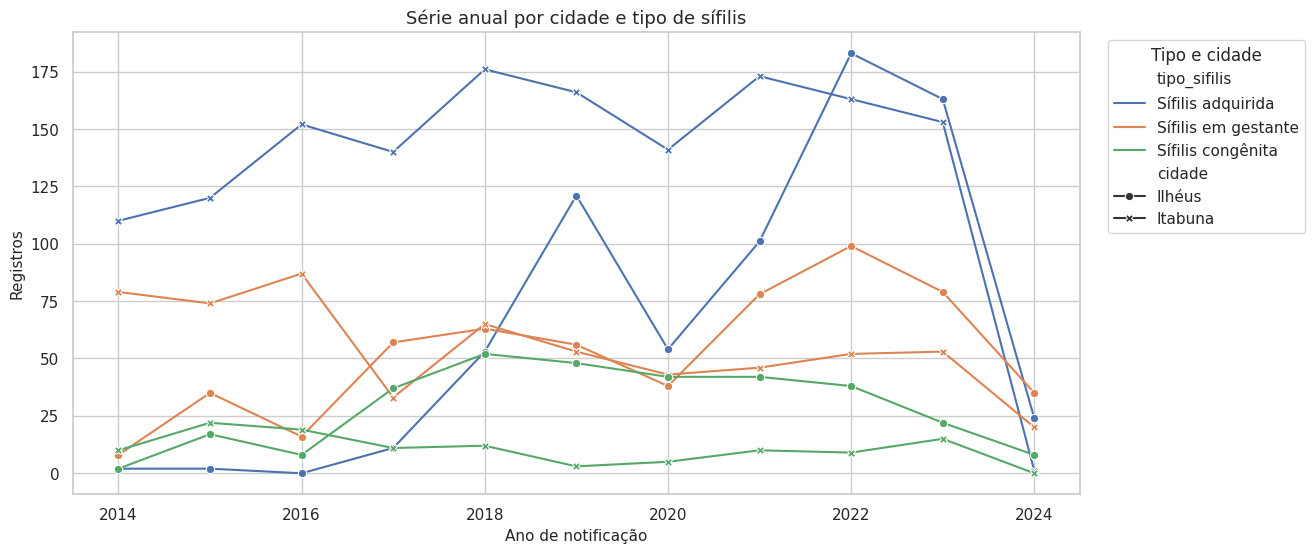

In [7]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(
    data=cidades_ano_completo,
    x="ano_notificacao",
    y="casos",
    hue="tipo_sifilis",
    style="cidade",
    markers=True,
    dashes=False,
    ax=ax,
)
ax.set_title("Série anual por cidade e tipo de sífilis")
ax.set_xlabel("Ano de notificação")
ax.set_ylabel("Registros")
ax.legend(title="Tipo e cidade", bbox_to_anchor=(1.02, 1), loc="upper left")
salvar_figura(fig, OUTPUT_DIR, "01_serie_anual_cidades.png")
plt.show()

## Participação das cidades no total da Bahia

In [8]:
participacao_ano.head()

,ano_notificacao,tipo_sifilis,casos_ilheus_itabuna,casos_bahia,participacao_pct
0,2014,Sífilis adquirida,112,1464,7.650273
1,2014,Sífilis congênita,12,933,1.286174
2,2014,Sífilis em gestante,87,1778,4.893138
3,2015,Sífilis adquirida,122,2206,5.530372
4,2015,Sífilis congênita,39,1185,3.291139


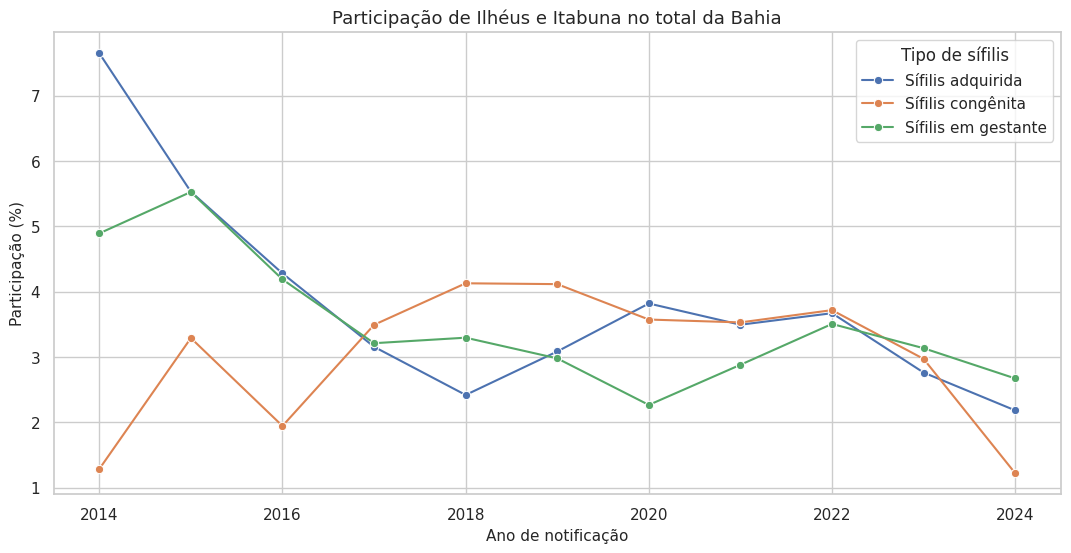

In [9]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(
    data=participacao_ano,
    x="ano_notificacao",
    y="participacao_pct",
    hue="tipo_sifilis",
    marker="o",
    ax=ax,
)
ax.set_title("Participação de Ilhéus e Itabuna no total da Bahia")
ax.set_xlabel("Ano de notificação")
ax.set_ylabel("Participação (%)")
ax.legend(title="Tipo de sífilis")
salvar_figura(fig, OUTPUT_DIR, "01_participacao_cidades_bahia.png")
plt.show()

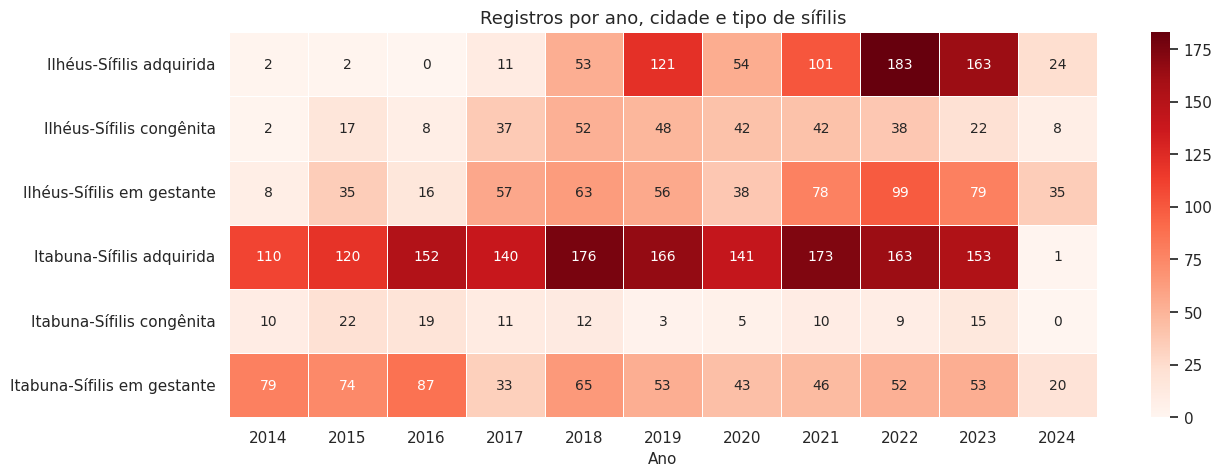

In [10]:
heat = cidades_ano_completo.pivot_table(
    index=["cidade", "tipo_sifilis"],
    columns="ano_notificacao",
    values="casos",
    aggfunc="sum",
    fill_value=0,
)
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="Reds", linewidths=.4, ax=ax)
ax.set_title("Registros por ano, cidade e tipo de sífilis")
ax.set_xlabel("Ano")
ax.set_ylabel("")
salvar_figura(fig, OUTPUT_DIR, "01_heatmap_cidade_tipo_ano.png")
plt.show()

In [11]:
resumo_validacao = pd.DataFrame({
    "indicador": ["arquivos_lidos", "registros_bahia", "registros_ilheus_itabuna", "anos_inicial", "anos_final", "cache_faltantes"],
    "valor": [
        len(resumo_arquivos),
        total_bahia,
        len(df_cidades),
        int(df_cidades["ano_notificacao"].min()),
        int(df_cidades["ano_notificacao"].max()),
        status_cache["total_faltante"],
    ],
})
resumo_validacao

,indicador,valor
0,arquivos_lidos,33
1,registros_bahia,114346
2,registros_ilheus_itabuna,3810
3,anos_inicial,2014
4,anos_final,2024
5,cache_faltantes,0
